In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    matthews_corrcoef
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [12]:
# Load dataset
df = pd.read_csv("Data_Sheet_Ground_Water.csv")
# Inspect
print(df.shape)
df.head(2)

(42, 20)


,Site,Year,pH,Odour,Turbidity,Conductivity,Chloride (ppm),Sulphates(ppm),Iron (ppm),COD(ppm),BOD(ppm),DO(ppm),Lead(ppm),Ammonia(ppm),Nitrate(ppm),Fluorides(ppm),Phosphates(ppm),Total Bacterial Count (cfu/ml),Total Fungal Count (cfu/ml),Pesticide (µg/l)
0,Karan Lake (Site 1) (Ground Water),2016,7.5,NO,0.4,246.0,112.4,65.0,0.4,23.0,16.02,6.2,ND,0.3,45.0,ND,ND,3000,200,ND
1,Karan Lake (Site 1) (Ground Water),2017,7.7,NO,0.5,276.0,122.0,76.0,0.5,23.5,16.40,6.0,ND,0.4,45.0,ND,ND,3000,200,ND


In [32]:
df = pd.read_csv("groundwater_cleaned.csv")

df.head()

,site,year,ph,odour,turbidity,conductivity,chloride_(ppm),sulphates(ppm),iron_(ppm),cod(ppm),bod(ppm),do(ppm),lead(ppm),ammonia(ppm),nitrate(ppm),fluorides(ppm),phosphates(ppm),total_bacterial_count_(cfu/ml),total_fungal_count_(cfu/ml),pesticide_(µg/l)
0,Karan Lake (Site 1) (Ground Water),2016,7.50,NaN,0.40,246.0,112.4,65.0,0.4,23.0,16.02,6.2,NaN,0.3,45.0,NaN,NaN,3000,200.0,NaN
1,Karan Lake (Site 1) (Ground Water),2017,7.70,NaN,0.50,276.0,122.0,76.0,0.5,23.5,16.40,6.0,NaN,0.4,45.0,NaN,NaN,3000,200.0,NaN
2,Karan Lake (Site 1) (Ground Water),2018,7.90,NaN,0.60,296.0,129.9,93.0,0.6,24.8,17.80,5.9,NaN,0.6,45.0,NaN,NaN,3000,200.0,NaN
3,Brahma Sarovar(Site 2) (Ground Water ),2016,7.61,NaN,0.20,294.0,121.9,60.0,0.5,31.3,19.20,7.2,NaN,0.3,45.0,NaN,NaN,800,NaN,NaN
4,Brahma Sarovar(Site 2) (Ground Water ),2017,7.60,NaN,0.21,300.0,121.8,60.0,0.7,34.2,20.20,6.2,NaN,0.3,51.0,NaN,NaN,900,NaN,NaN


In [52]:
df = pd.read_csv("gw_sanity.csv")
df.head(4)

,site,year,ph,odour,turbidity,conductivity,chloride_(ppm),sulphates(ppm),iron_(ppm),cod(ppm),bod(ppm),do(ppm),lead(ppm),ammonia(ppm),nitrate(ppm),fluorides(ppm),phosphates(ppm),total_bacterial_count_(cfu/ml),total_fungal_count_(cfu/ml),pesticide_(µg/l)
0,Karan Lake (Site 1) (Ground Water),2016,7.50,NaN,0.4,246.0,112.4,65.0,0.4,23.0,16.02,6.2,NaN,0.3,45.0,NaN,NaN,3000,200.0,NaN
1,Karan Lake (Site 1) (Ground Water),2017,7.70,NaN,0.5,276.0,122.0,76.0,0.5,23.5,16.40,6.0,NaN,0.4,45.0,NaN,NaN,3000,200.0,NaN
2,Karan Lake (Site 1) (Ground Water),2018,7.90,NaN,0.6,296.0,129.9,93.0,0.6,24.8,17.80,5.9,NaN,0.6,45.0,NaN,NaN,3000,200.0,NaN
3,Brahma Sarovar(Site 2) (Ground Water ),2016,7.61,NaN,0.2,294.0,121.9,60.0,0.5,31.3,19.20,7.2,NaN,0.3,45.0,NaN,NaN,800,NaN,NaN


In [53]:
#DATASET VERIFICATION
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   site                            42 non-null     object 
 1   year                            42 non-null     int64  
 2   ph                              42 non-null     float64
 3   odour                           0 non-null      float64
 4   turbidity                       42 non-null     float64
 5   conductivity                    42 non-null     float64
 6   chloride_(ppm)                  42 non-null     float64
 7   sulphates(ppm)                  42 non-null     float64
 8   iron_(ppm)                      42 non-null     float64
 9   cod(ppm)                        42 non-null     float64
 10  bod(ppm)                        42 non-null     float64
 11  do(ppm)                         42 non-null     float64
 12  lead(ppm)                       0 non-

In [54]:
df.describe()

,year,ph,odour,turbidity,conductivity,chloride_(ppm),sulphates(ppm),iron_(ppm),cod(ppm),bod(ppm),do(ppm),lead(ppm),ammonia(ppm),nitrate(ppm),fluorides(ppm),phosphates(ppm),total_bacterial_count_(cfu/ml),total_fungal_count_(cfu/ml),pesticide_(µg/l)
count,42.000000,42.000000,0.0,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,0.0,42.000000,42.000000,15.000000,6.000000,42.000000,24.000000,0.0
mean,2017.000000,7.596429,NaN,0.910714,562.004762,115.068095,69.833333,1.275476,22.499762,16.359048,5.209524,NaN,0.840238,32.854762,1.650667,5.750000,2933.142857,538.750000,NaN
std,0.826394,0.213357,NaN,0.776387,218.231206,101.013433,29.792720,1.965861,6.427395,7.943655,1.826473,NaN,1.027753,24.577614,0.972166,0.725948,3894.979161,422.194706,NaN
min,2016.000000,7.200000,NaN,0.200000,246.000000,17.000000,13.500000,0.200000,9.080000,5.540000,1.100000,NaN,0.200000,10.000000,0.370000,5.000000,600.000000,100.000000,NaN
25%,2016.000000,7.500000,NaN,0.477500,350.500000,45.932500,50.250000,0.500000,18.207500,9.725000,3.925000,NaN,0.300000,14.000000,0.900000,5.250000,800.000000,137.500000,NaN
50%,2017.000000,7.600000,NaN,0.600000,557.500000,85.240000,66.500000,0.600000,22.850000,15.790000,5.850000,NaN,0.400000,22.500000,1.500000,5.650000,2200.000000,500.000000,NaN
75%,2018.000000,7.700000,NaN,1.150000,728.500000,153.710000,85.750000,1.125000,26.675000,19.950000,6.275000,NaN,1.025000,45.000000,2.000000,5.975000,2925.000000,850.000000,NaN
max,2018.000000,8.140000,NaN,2.900000,963.000000,393.560000,163.000000,9.170000,34.200000,39.400000,8.600000,NaN,4.800000,92.500000,3.700000,7.000000,17000.000000,1300.000000,NaN


In [55]:
df.isnull().sum()

site                               0
year                               0
ph                                 0
odour                             42
turbidity                          0
conductivity                       0
chloride_(ppm)                     0
sulphates(ppm)                     0
iron_(ppm)                         0
cod(ppm)                           0
bod(ppm)                           0
do(ppm)                            0
lead(ppm)                         42
ammonia(ppm)                       0
nitrate(ppm)                       0
fluorides(ppm)                    27
phosphates(ppm)                   36
total_bacterial_count_(cfu/ml)     0
total_fungal_count_(cfu/ml)       18
pesticide_(µg/l)                  42
dtype: int64

In [56]:
#PARAMETER MAPPING
param_map={
    'ph':'ph',
    'turbidity':'turbidity',
    'chloride':'chloride_(ppm)',
    'sulphate':'sulphates(ppm)',
    'nitrate':'nitrate(ppm)',
    'iron':'iron_(ppm)',
    'fluoride':'fluorides(ppm)',
    'conductivity':'conductiv'
}
#BIS WQI CALCULATION
def compute_bis_wqi(df):

    bis_limits={
        "ph":(6.5,8.5),
        "turbidity":5,
        "chloride":250,
        "sulphate":200,
        "nitrate":45,
        "fluoride":1.5,
        "iron":0.3,
        "conductivity":2000
    }

    weights={k:1/v if not isinstance(v,tuple) else 1/v[1]
             for k,v in bis_limits.items()}

    wqi_vals=[]

    for _,row in df.iterrows():

        num=0
        den=0

        for p,limit in bis_limits.items():

            col=param_map[p]

            if col not in df.columns or pd.isna(row[col]):
                continue

            wi=weights[p]

            if p=="ph":
                qi=abs(row[col]-7.0)/(8.5-7.0)*100
            else:
                qi=(row[col]/limit)*100

            num+=wi*qi
            den+=wi

        wqi_vals.append(num/den if den!=0 else np.nan)

    df["wqi"]=wqi_vals

    return df

In [57]:
df = compute_bis_wqi(df)

In [58]:
#CREATE WQI CLASSES
def wqi_class(wqi):
    if wqi <= 50:
        return "Excellent"
    elif wqi <= 100:
        return "Good"
    elif wqi <= 200:
        return "Poor"
    elif wqi <= 300:
        return "Very Poor"
    else:
        return "Unsuitable"

In [59]:
df["wqi_class"] = df["wqi"].apply(wqi_class)

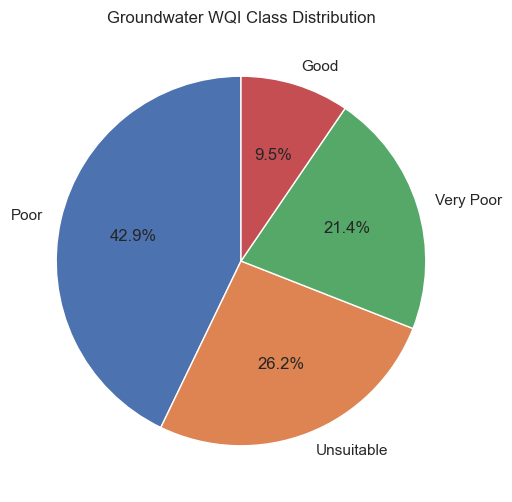

In [60]:
#PIE CHART: CLASS DISTRIBUTION
plt.figure(figsize=(6,6))

df["wqi_class"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Groundwater WQI Class Distribution")

plt.ylabel("")
plt.show()

In [61]:
#ENCODED CLASSES
le = LabelEncoder()
df["wqi_encoded"] = le.fit_transform(df["wqi_class"])

In [62]:
#FEATURE SELECTION: Only numeric predictors.
#X = df.drop(columns=["wqi","wqi_class","wqi_encoded"])
#y = df["wqi_encoded"]

X = df.select_dtypes(include=[np.number]).drop(columns=["wqi","wqi_encoded"])
y = df["wqi_encoded"]

In [63]:
#TRAIN-TEST SPLIT: Stratified split preserves class distribution
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
df["wqi"].isna().sum()

0

In [75]:
X.isna().sum().sort_values(ascending=False)

pesticide_(µg/l)                  42
odour                             42
lead(ppm)                         42
phosphates(ppm)                   36
fluorides(ppm)                    27
total_fungal_count_(cfu/ml)       18
do(ppm)                            0
total_bacterial_count_(cfu/ml)     0
nitrate(ppm)                       0
ammonia(ppm)                       0
year                               0
ph                                 0
cod(ppm)                           0
iron_(ppm)                         0
sulphates(ppm)                     0
chloride_(ppm)                     0
conductivity                       0
turbidity                          0
bod(ppm)                           0
dtype: int64

In [104]:
from sklearn.impute import SimpleImputer
#Median is preferred because water-quality data often has outliers.
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [142]:
# FEATURE SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [143]:
print(y_train.unique())

[1 2 3 0]


In [144]:
#MODEL TRAINING
models = {

"Random Forest":RandomForestClassifier(random_state=42),

"Gradient Boosting":GradientBoostingClassifier(random_state=42),

"SVM":SVC(),

"KNN":KNeighborsClassifier(),

"Decision Tree":DecisionTreeClassifier(random_state=42),

"XGBoost":XGBClassifier(use_label_encoder=False,eval_metric="mlogloss")

}

In [145]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv5 = cross_val_score(model, X_train, y_train, cv=kf5, scoring="accuracy")
cv10 = cross_val_score(model, X_train, y_train, cv=kf10, scoring="accuracy")

results = []
kf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred, average="weighted")

    recall = recall_score(y_test, y_pred, average="weighted")

    f1 = f1_score(y_test, y_pred, average="weighted")

    mcc = matthews_corrcoef(y_test, y_pred)

    cv5 = cross_val_score(model, X_train, y_train, cv=kf5, scoring="accuracy")

    cv10 = cross_val_score(model, X_train, y_train, cv=kf10, scoring="accuracy")

    results.append([
        name,
        acc,
        precision,
        recall,
        f1,
        mcc,
        f"{cv5.mean():.3f} ± {cv5.std():.3f}",
        f"{cv10.mean():.3f} ± {cv10.std():.3f}"
    ])


In [146]:
columns = [
"Model",
"Accuracy",
"Precision",
"Recall",
"F1 Score",
"MCC",
"5 Fold Accuracy",
"10 Fold Accuracy"
]

results_df = pd.DataFrame(results, columns=columns)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,MCC,5 Fold Accuracy,10 Fold Accuracy
0,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,0.886 ± 0.140,0.892 ± 0.135
1,Gradient Boosting,1.000000,1.000000,1.000000,1.000000,1.000000,1.000 ± 0.000,0.967 ± 0.100
4,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000,1.000 ± 0.000,1.000 ± 0.000
5,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000,0.886 ± 0.107,0.900 ± 0.166
2,SVM,0.777778,0.740741,0.777778,0.725926,0.697252,0.610 ± 0.102,0.617 ± 0.076
3,KNN,0.777778,0.833333,0.777778,0.777778,0.696429,0.452 ± 0.270,0.450 ± 0.198


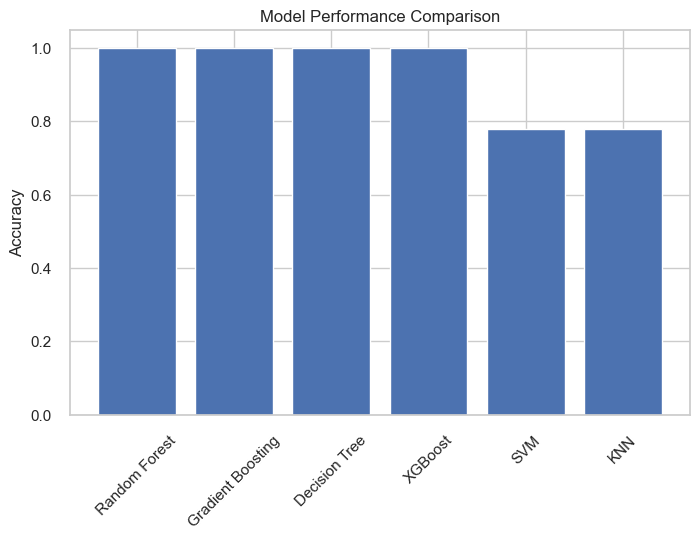

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.show()

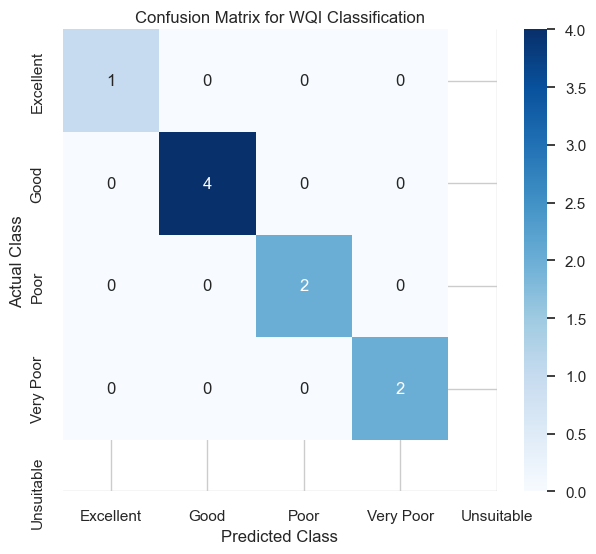

In [148]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# predictions
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

labels = ["Excellent","Good","Poor","Very Poor","Unsuitable"]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix for WQI Classification")

plt.show()

In [149]:
print(len(rf.feature_importances_))
print(len(X.columns))

16
19


In [150]:
#Random Forest Feature Importance
# This shows which water parameters influence WQI the most.
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

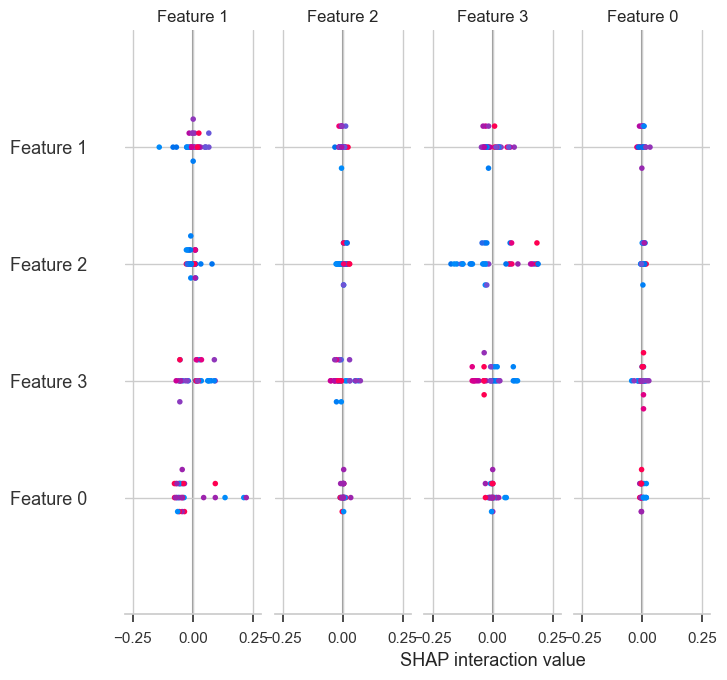

In [153]:
#SHAP ANALYSIS
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

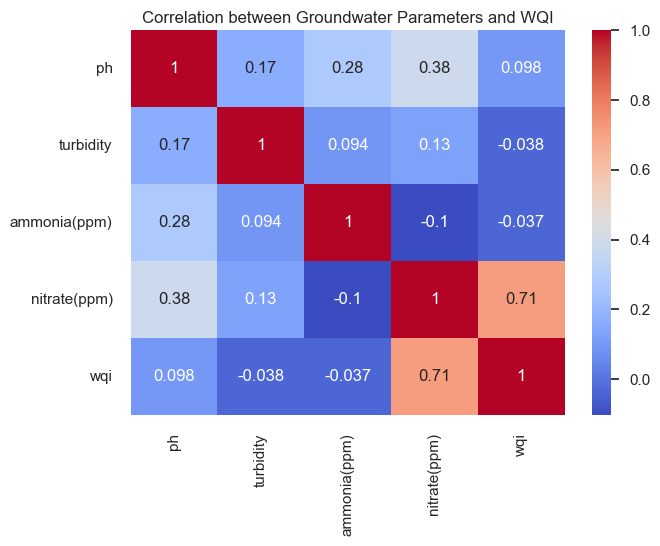

In [154]:
#Parameter Influence on WQI
import seaborn as sns
params = ['ph', 'turbidity', 'ammonia(ppm)', 'nitrate(ppm)', 'wqi']

df = compute_bis_wqi(df)

corr_df = df[params].apply(pd.to_numeric, errors='coerce')
corr = corr_df.corr()

import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between Groundwater Parameters and WQI")
plt.show()

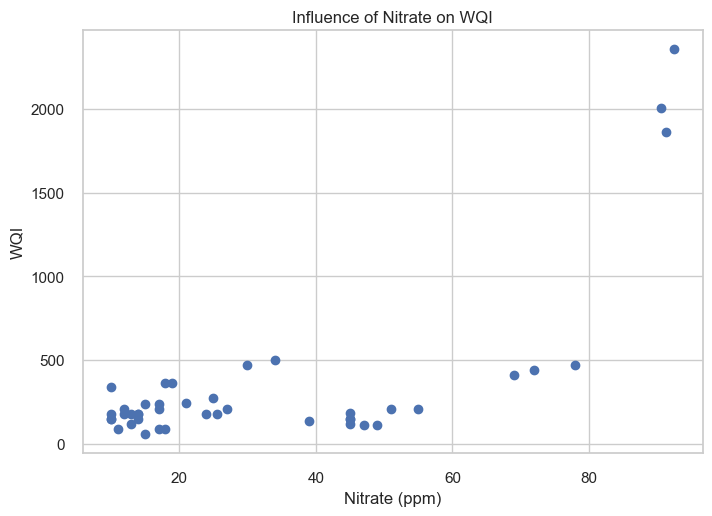

In [155]:
#PARAMETER VS WQI INFLUENCE PLOTS
plt.scatter(df["nitrate(ppm)"], df["wqi"])

plt.ylabel("WQI")

plt.title("Influence of Nitrate on WQI")

plt.xlabel("Nitrate (ppm)")
plt.show()

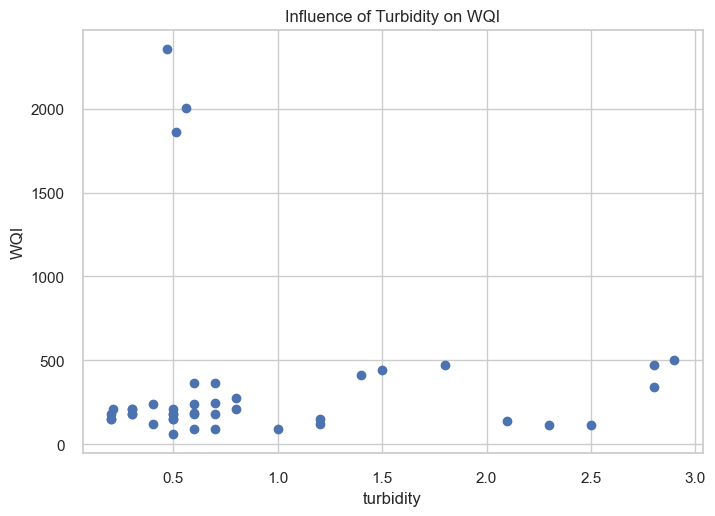

In [156]:
#PARAMETER VS WQI INFLUENCE PLOTS
plt.scatter(df["turbidity"], df["wqi"])

plt.xlabel("turbidity")
plt.ylabel("WQI")

plt.title("Influence of Turbidity on WQI")

plt.show()

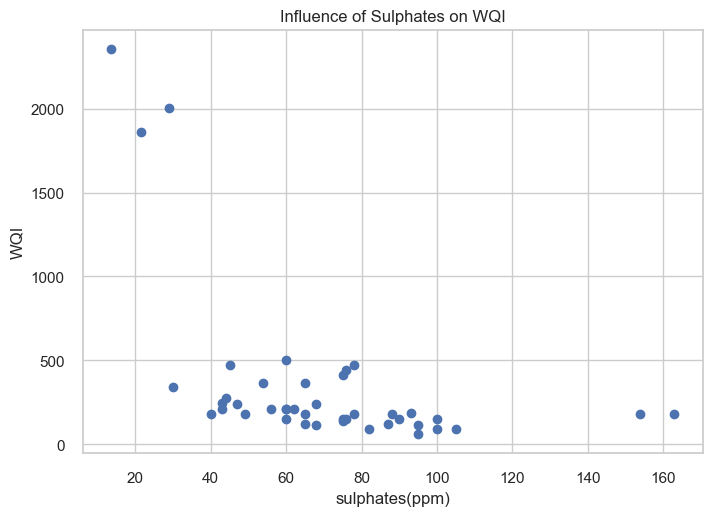

In [157]:
#PARAMETER VS WQI INFLUENCE PLOTS
plt.scatter(df["sulphates(ppm)"], df["wqi"])

plt.xlabel("sulphates(ppm)")
plt.ylabel("WQI")

plt.title("Influence of Sulphates on WQI")

plt.show()

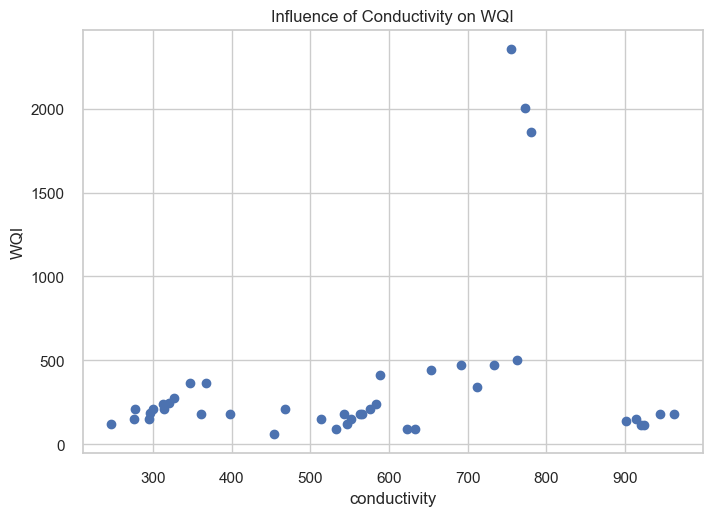

In [158]:
#PARAMETER VS WQI INFLUENCE PLOTS
plt.scatter(df["conductivity"], df["wqi"])

plt.xlabel("conductivity")
plt.ylabel("WQI")

plt.title("Influence of Conductivity on WQI")

plt.show()

In [161]:
df.head(3)

,site,year,ph,odour,turbidity,conductivity,chloride_(ppm),sulphates(ppm),iron_(ppm),cod(ppm),...,ammonia(ppm),nitrate(ppm),fluorides(ppm),phosphates(ppm),total_bacterial_count_(cfu/ml),total_fungal_count_(cfu/ml),pesticide_(µg/l),wqi,wqi_class,wqi_encoded
0,Karan Lake (Site 1) (Ground Water),2016,7.5,NaN,0.4,246.0,112.4,65.0,0.4,23.0,...,0.3,45.0,NaN,NaN,3000,200.0,NaN,122.896707,Poor,1
1,Karan Lake (Site 1) (Ground Water),2017,7.7,NaN,0.5,276.0,122.0,76.0,0.5,23.5,...,0.4,45.0,NaN,NaN,3000,200.0,NaN,153.618156,Poor,1
2,Karan Lake (Site 1) (Ground Water),2018,7.9,NaN,0.6,296.0,129.9,93.0,0.6,24.8,...,0.6,45.0,NaN,NaN,3000,200.0,NaN,184.342939,Poor,1
